# 🎛️ Filtros Digitais com Python
por: **Iury Coelho**

Um **filtro** é um sistema LTI que modela o conteúdo de frequência de um sinal,
realçando algumas faixas e atenuando outras. Este notebook cobre os tipos
básicos (passa-baixa, passa-alta, passa-banda, rejeita-banda), a **resposta em
frequência**, o projeto de filtros **FIR** e **IIR** com SciPy e uma aplicação
prática: **remover ruído** de um sinal.

#### Conteúdo
* [1. Resposta em frequência](#1)
* [2. Filtro FIR](#2)
* [3. Filtro IIR (Butterworth)](#3)
* [4. FIR × IIR](#4)
* [5. Aplicação: removendo ruído](#5)
* [6. Filtragem de áudio](#6)
* [7. Exercícios](#7)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as ss
from IPython.display import Audio, display

plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

def db(h):
    # magnitude em decibeis, protegida contra log(0)
    return 20*np.log10(np.maximum(np.abs(h), 1e-12))

<a id="1"></a>
## 1. Resposta em frequência

> __Definição__
> A **resposta em frequência** $H(e^{j\omega})$ de um filtro descreve seu ganho
> e sua fase para cada frequência. A magnitude $|H(e^{j\omega})|$ diz o quanto
> cada frequência é amplificada (ganho $>1$) ou atenuada (ganho $<1$).

O filtro mais simples é a **média móvel** de $M$ pontos — um FIR cujos
coeficientes são todos iguais a $1/M$:
$$ y[n] = \frac{1}{M}\sum_{k=0}^{M-1} x[n-k]. $$
Ele já é um **passa-baixa**: suaviza o sinal e atenua as altas frequências.

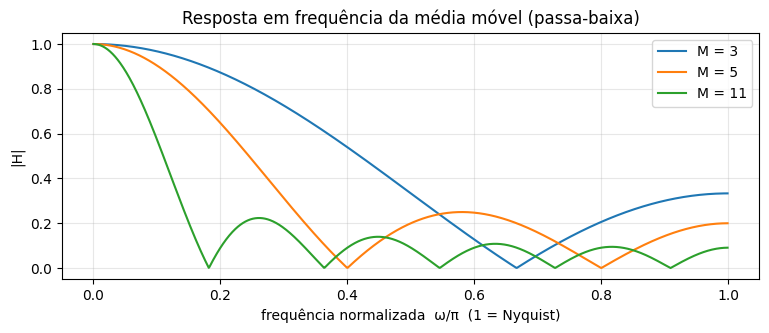

In [2]:
for M in [3, 5, 11]:
    b = np.ones(M)/M            # coeficientes do FIR media movel
    w, h = ss.freqz(b, 1, worN=1024)
    plt.plot(w/np.pi, np.abs(h), label=f"M = {M}")
plt.title("Resposta em frequência da média móvel (passa-baixa)")
plt.xlabel("frequência normalizada  ω/π  (1 = Nyquist)")
plt.ylabel("|H|"); plt.legend(); plt.show()

<a id="2"></a>
## 2. Filtro FIR projetado por janela

Para controlar a frequência de corte, projetamos um FIR com
`scipy.signal.firwin`. Filtros FIR têm **fase linear** (não distorcem a forma de
onda) e são sempre estáveis. Abaixo, um passa-baixa com corte em 100 Hz para um
sinal amostrado a $f_s = 1000$ Hz.

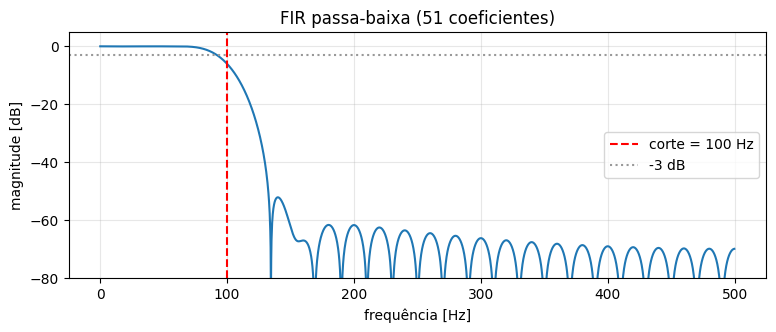

In [3]:
fs = 1000
fc = 100
numtaps = 51
b_fir = ss.firwin(numtaps, cutoff=fc, fs=fs)   # passa-baixa de fase linear

w, h = ss.freqz(b_fir, 1, fs=fs, worN=2048)
plt.plot(w, db(h))
plt.axvline(fc, color="r", ls="--", label=f"corte = {fc} Hz")
plt.axhline(-3, color="0.6", ls=":", label="-3 dB")
plt.title(f"FIR passa-baixa ({numtaps} coeficientes)")
plt.xlabel("frequência [Hz]"); plt.ylabel("magnitude [dB]")
plt.ylim(-80, 5); plt.legend(); plt.show()

<a id="3"></a>
## 3. Filtro IIR (Butterworth)

Filtros **IIR** atingem uma transição mais abrupta com **menos coeficientes**
que um FIR equivalente, ao custo de fase não linear e da necessidade de cuidar
da estabilidade. O **Butterworth** tem resposta maximamente plana na banda
passante. Usamos a forma `sos` (seções de 2ª ordem), numericamente robusta.

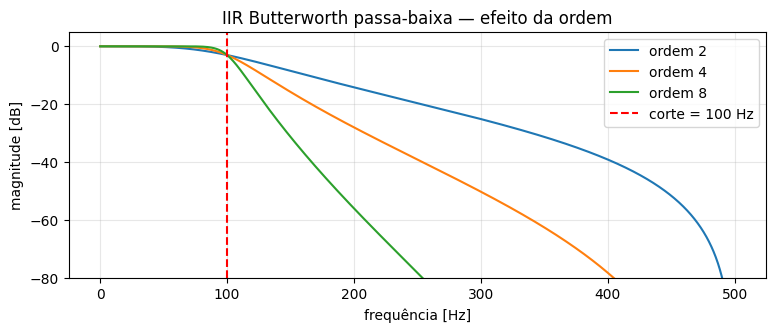

In [4]:
fs = 1000
fc = 100
for ordem in [2, 4, 8]:
    sos = ss.butter(ordem, fc, btype="low", fs=fs, output="sos")
    w, h = ss.sosfreqz(sos, fs=fs, worN=2048)
    plt.plot(w, db(h), label=f"ordem {ordem}")
plt.axvline(fc, color="r", ls="--", label=f"corte = {fc} Hz")
plt.title("IIR Butterworth passa-baixa — efeito da ordem")
plt.xlabel("frequência [Hz]"); plt.ylabel("magnitude [dB]")
plt.ylim(-80, 5); plt.legend(); plt.show()

<a id="4"></a>
## 4. FIR × IIR

Comparando, para o mesmo corte: o IIR de ordem 8 (poucos coeficientes) rivaliza
com o FIR de 51 coeficientes na seletividade. A escolha depende do que importa:
**fase linear e estabilidade garantida** (FIR) ou **eficiência computacional**
(IIR).

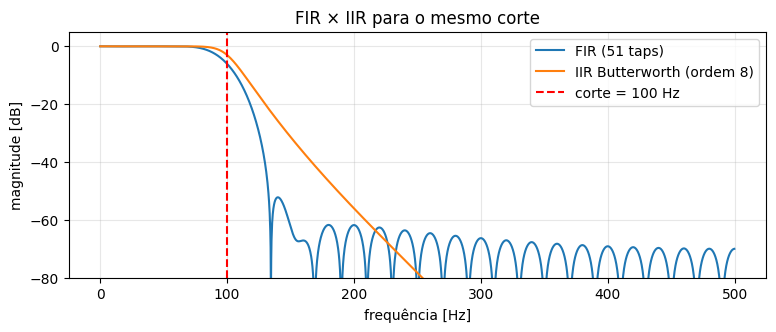

In [5]:
fs, fc = 1000, 100
b_fir = ss.firwin(51, fc, fs=fs)
sos_iir = ss.butter(8, fc, btype="low", fs=fs, output="sos")

w1, h1 = ss.freqz(b_fir, 1, fs=fs, worN=2048)
w2, h2 = ss.sosfreqz(sos_iir, fs=fs, worN=2048)
plt.plot(w1, db(h1), label="FIR (51 taps)")
plt.plot(w2, db(h2), label="IIR Butterworth (ordem 8)")
plt.axvline(fc, color="r", ls="--", label=f"corte = {fc} Hz")
plt.title("FIR × IIR para o mesmo corte")
plt.xlabel("frequência [Hz]"); plt.ylabel("magnitude [dB]")
plt.ylim(-80, 5); plt.legend(); plt.show()

<a id="5"></a>
## 5. Aplicação: removendo ruído

Um sinal útil de **5 Hz** é contaminado por uma interferência de **200 Hz**.
Um passa-baixa com corte em 50 Hz recupera o sinal. Usamos `sosfiltfilt`
(filtragem de **fase zero**: aplica o filtro para frente e para trás, sem
atraso).

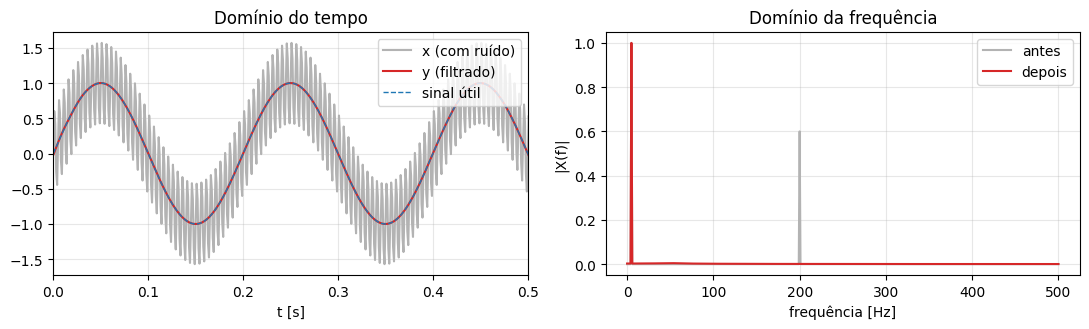

In [6]:
fs = 1000
t = np.arange(0, 1, 1/fs)
util = np.sin(2*np.pi*5*t)
ruido = 0.6*np.sin(2*np.pi*200*t)
x = util + ruido

sos = ss.butter(6, 50, btype="low", fs=fs, output="sos")
y = ss.sosfiltfilt(sos, x)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.plot(t, x, color="0.7", label="x (com ruído)")
a1.plot(t, y, "C3", label="y (filtrado)")
a1.plot(t, util, "C0--", lw=1, label="sinal útil")
a1.set_xlim(0, 0.5); a1.set_title("Domínio do tempo")
a1.set_xlabel("t [s]"); a1.legend(loc="upper right")

for sig, lab, c in [(x, "antes", "0.7"), (y, "depois", "C3")]:
    f = np.fft.rfftfreq(len(sig), 1/fs)
    a2.plot(f, np.abs(np.fft.rfft(sig))/len(sig)*2, color=c, label=lab)
a2.set_title("Domínio da frequência"); a2.set_xlabel("frequência [Hz]")
a2.set_ylabel("|X(f)|"); a2.legend()
plt.tight_layout(); plt.show()

<a id="6"></a>
## 6. Filtragem de áudio

Um sinal com três tons (200, 1000 e 3000 Hz) é processado por um **passa-banda**
centrado em 1000 Hz. Depois de filtrar, sobra essencialmente o tom do meio —
dá para **ouvir** a diferença.

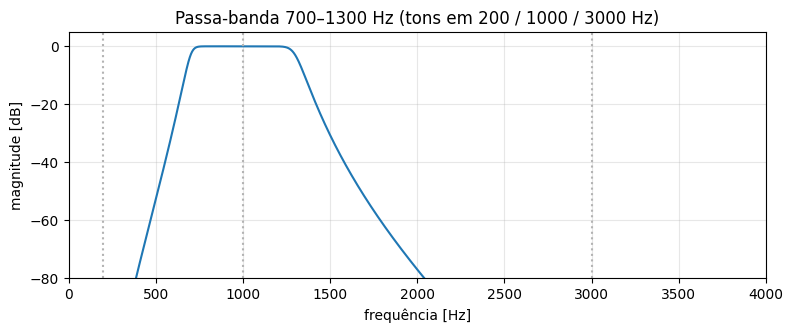

Antes (três tons):


Depois (passa-banda em 1000 Hz):


In [7]:
fs = 8000
dur = 1.5
t = np.linspace(0, dur, int(fs*dur), endpoint=False)
tons = [200, 1000, 3000]
x = sum(np.sin(2*np.pi*f*t) for f in tons) / len(tons)

sos = ss.butter(8, [700, 1300], btype="band", fs=fs, output="sos")
y = ss.sosfiltfilt(sos, x)

w, h = ss.sosfreqz(sos, fs=fs, worN=4096)
plt.plot(w, db(h))
for f in tons:
    plt.axvline(f, color="0.7", ls=":")
plt.title("Passa-banda 700–1300 Hz (tons em 200 / 1000 / 3000 Hz)")
plt.xlabel("frequência [Hz]"); plt.ylabel("magnitude [dB]")
plt.ylim(-80, 5); plt.xlim(0, 4000); plt.show()

print("Antes (três tons):")
display(Audio(x, rate=fs))
print("Depois (passa-banda em 1000 Hz):")
display(Audio(y, rate=fs))

<a id="7"></a>
## 7. Exercícios

__Exercício 1__ — Um sensor produz um sinal de 8 Hz montado sobre uma deriva
lenta (nível DC variando a 0,5 Hz). Projete um **passa-altas** que remova a
deriva e preserve os 8 Hz.

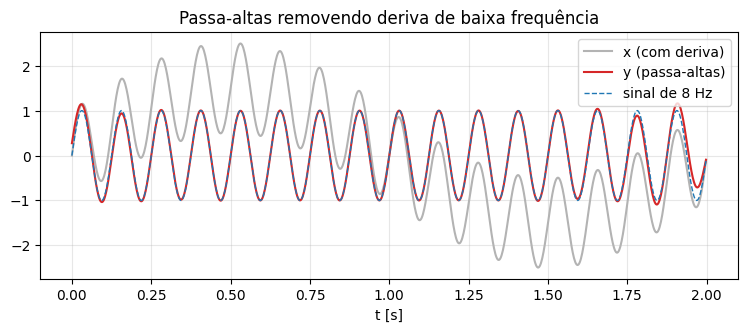

In [8]:
fs = 500
t = np.arange(0, 2, 1/fs)
sinal = np.sin(2*np.pi*8*t)
deriva = 1.5*np.sin(2*np.pi*0.5*t)        # componente lenta indesejada
x = sinal + deriva

sos = ss.butter(4, 3, btype="high", fs=fs, output="sos")   # corte em 3 Hz
y = ss.sosfiltfilt(sos, x)

plt.plot(t, x, color="0.7", label="x (com deriva)")
plt.plot(t, y, "C3", label="y (passa-altas)")
plt.plot(t, sinal, "C0--", lw=1, label="sinal de 8 Hz")
plt.title("Passa-altas removendo deriva de baixa frequência")
plt.xlabel("t [s]"); plt.legend(loc="upper right"); plt.show()

__Resposta__: um passa-altas Butterworth com corte em 3 Hz rejeita a deriva de
0,5 Hz (bem abaixo do corte) e deixa passar os 8 Hz com pouca alteração.

---

__Exercício 2__ — Por que, ao filtrar um registro já gravado, costuma-se preferir
`sosfiltfilt` (fase zero) a `sosfilt`?

__Resposta__: `sosfilt` aplica o filtro uma vez e introduz **atraso de fase**
(que varia com a frequência em filtros IIR), deslocando e distorcendo a forma de
onda. `sosfiltfilt` aplica o filtro nos dois sentidos: os atrasos se cancelam,
resultando em **fase zero** e nenhuma defasagem — ideal para processamento
*offline*, quando todo o sinal já está disponível. Em tempo real não é possível
(exigiria conhecer o futuro), e aí se usa `sosfilt`.

---
<br>[⬆ volte ao topo](#Conteúdo)